# DT-letter flat-top beam shaping in the far field

This notebook designs a **phase-only flat-optics element** that transforms a Gaussian input beam into a DT-letter target in the far field. The phase is found with a physics-informed neural network (PINN) that solves the far-field Monge--Ampère beam-shaping equation, and the result is compared with a Gerchberg--Saxton (GS) baseline.

The main workflow is:

1. define the Gaussian source and DT target in angular coordinates $(\alpha,\beta)$,
2. train or load the PINN phase profile,
3. validate the learned phase using scalar far-field diffraction,
4. run GS for the same source and target, and
5. compare profile error, cross sections, and energy efficiency.

## Imports and numerical backend

The code uses **PyTorch** for the PINN and automatic differentiation, NumPy/Matplotlib for array manipulation and plotting, and the local `pinn_shaper` package for the Monge--Amp\`ere solver. If a CUDA GPU is available, PyTorch tensors are placed on the GPU by default.

In [1]:
# import the neccesary modules
import torch
if torch.cuda.is_available():
    torch.set_default_device('cuda')
    
import pinn_shaper
from pinn_shaper import Farfield_PINN
from pinn_shaper import um, mm, cm
import matplotlib.pyplot as plt
import numpy as np
from pinn_shaper import load_image, create_interpolator
from scipy.ndimage import gaussian_filter as scipy_gaussian_filter


## Problem setup: Gaussian source and DT target

The incident irradiance is a circular Gaussian,

$$
I(x,y)=\exp\!\left[-2\left(\frac{\sqrt{x^2+y^2}}{w_I}\right)^2\right],
$$

sampled over a square source aperture. The desired far-field radiant intensity is specified in direction-cosine coordinates $(\alpha,\beta)$ by loading and smoothing a DT-logo image. The image is converted into a differentiable interpolator over $[-1,1]\times[-1,1]$, so that the PINN can evaluate

$$
I_{e,\Omega\cos\theta}(\alpha,\beta)
$$

at arbitrary mapped coordinates during training.

For the far-field formulation, the learned normalized phase $\bar\Phi$ maps source points directly into angular coordinates through

$$
(\alpha,\beta)=\left(\bar\Phi_{\bar x},\bar\Phi_{\bar y}\right),
$$

and the residual is based on

$$
I_{e,\Omega\cos\theta}\!\left(\bar\Phi_{\bar x},\bar\Phi_{\bar y}\right)
\left|\bar\Phi_{\bar x\bar x}\bar\Phi_{\bar y\bar y}-\bar\Phi_{\bar x\bar y}^{2}\right|
= M^2 I(M\bar x,M\bar y).
$$

The PINN used here is a fully connected network with 4 hidden layers and 150 neurons per layer.

In [3]:
extent_source = 1000*um
w_I = 50.6 * um / (100 * um) * extent_source /2
λ = 1.0* um

def I_fun(x,y):
    # Source function. Gaussian beam with beam waist = w_I
    r = torch.sqrt(x**2+ y**2)
    return torch.exp(-(r/w_I)**2)**2

# Define the target function
w_E_α = np.sin(np.pi / 6)
w_E_β = np.sin(np.pi / 12)
n = 16
def Irad_fun(α, β):
    # Target function. Flat-Top beam
    return torch.exp(-2 * ((α / w_E_α))**n - 2 * ((β / w_E_β))**n)

image = np.array(scipy_gaussian_filter(load_image('images/DT.png'), 10, mode='nearest', cval=0), dtype = 'float32')
Irad_fun = create_interpolator(torch.tensor(image), mode='bilinear', region=[-1,1,-1,1], align_corners=True)


def constrain_fn(x):
    return x[:, 0:1]**2 + x[:, 1:2]**2


# Initialize the PINN solver (the network is built now)
solver = Farfield_PINN(I_fun, Irad_fun, extent_source, λ,
                        integration_points=5000,
                        hidden_layers=4, num_features=150,
                        constrain=True,  symmetry=None, 
                        constrain_fn = constrain_fn)

## Inspect the normalized source and target

These plots are a quick sanity check before training. The source plot shows the Gaussian aperture illumination, while the target plot shows the DT-logo radiant intensity distribution in the $(\alpha,\beta)$ far-field domain.

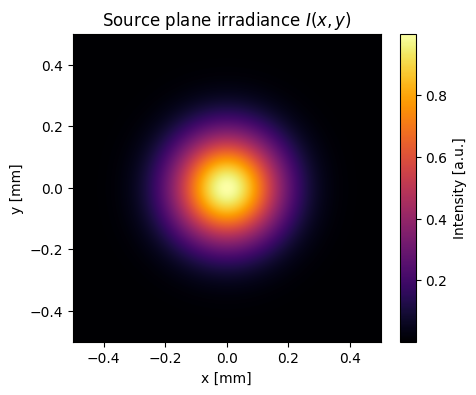

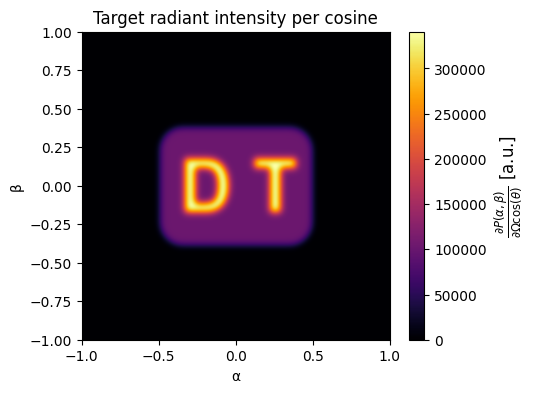

In [4]:
solver.plot_source_irradiance()
solver.plot_target_radiant_intensity()

## PINN training schedule

The phase network is optimized in stages. Adam first reduces the residual from a random initialization, and L-BFGS then refines the solution using larger batches of collocation points. The loss combines the Monge--Amp\`ere PDE residual with additional regularization/boundary terms through the `loss_weights` array.

The quantity `residual_power` changes how strongly large residuals are emphasized during training, while `num_domain` and `num_boundary` control the number of interior and boundary collocation points sampled in each phase.

In [18]:
# Define common parameters for test loss and noise
residual_power = 1.5
loss_weights = [100.0, 1, 1]
noise_amplitude = 0.0
add_noise = False
effective_noise = noise_amplitude if add_noise else 0.0
num_test_interior = 1000
num_test_boundary = 200

# Now the user calls run_phase three times, each with a single optimizer.
# For example, first two phases using Adam and the final phase using LBFGS.

print("Run Phase 1: Adam")
solver.run_phase(
    optimizer_type='adam',
    iterations=1000,
    num_domain=1000,
    num_boundary=100,
    residual_power=residual_power,
    loss_weights=loss_weights,
    effective_noise=effective_noise,
    num_test_interior=num_test_interior,
    num_test_boundary=num_test_boundary,
    lr=0.001
)

print("Run Phase 2: Adam")
solver.run_phase(
    optimizer_type='adam',
    iterations=2000,
    num_domain=1500*10,
    num_boundary=100*10,
    residual_power=residual_power,
    loss_weights=loss_weights,
    effective_noise=effective_noise,
    num_test_interior=num_test_interior,
    num_test_boundary=num_test_boundary,
    lr=0.0001
)

print("Run Phase 3: LBFGS")
solver.run_phase(
    optimizer_type='lbfgs',
    num_domain=1500*15,
    num_boundary=100*15,
    residual_power=residual_power,
    loss_weights=loss_weights,
    effective_noise=0.001,
    num_test_interior=num_test_interior,
    num_test_boundary=num_test_boundary,
    max_iterations_lbfgs=4000,
    lr_lbfgs=1
)


print("Run Phase 4: LBFGS")
solver.run_phase(
    optimizer_type='lbfgs',
    num_domain=1500*15,
    num_boundary=100*15,
    residual_power=residual_power,
    loss_weights=loss_weights,
    effective_noise=0.0,
    num_test_interior=num_test_interior,
    num_test_boundary=num_test_boundary,
    max_iterations_lbfgs=2800,
    lr_lbfgs=1
)

# Print final test losses.
solver.print_final_test_loss(num_test_interior, num_test_boundary, residual_power, loss_weights, effective_noise)


Run Phase 1: Adam
Adam Iter     0: Loss = 2.75754809 (Interior = 0.02757548, BC_x = 0.00000000, BC_y = 0.00000000)
           Test Loss = 2.61665440 (Interior = 0.02616654, BC_x = 0.00000000, BC_y = 0.00000000)
Adam Iter   100: Loss = 0.28646410 (Interior = 0.00286464, BC_x = 0.00000000, BC_y = 0.00000000)
           Test Loss = 0.28486425 (Interior = 0.00284864, BC_x = 0.00000000, BC_y = 0.00000000)
Adam Iter   200: Loss = 0.13903382 (Interior = 0.00139034, BC_x = 0.00000000, BC_y = 0.00000000)
           Test Loss = 0.13504866 (Interior = 0.00135049, BC_x = 0.00000000, BC_y = 0.00000000)
Adam Iter   300: Loss = 0.13003190 (Interior = 0.00130032, BC_x = 0.00000000, BC_y = 0.00000000)
           Test Loss = 0.12935436 (Interior = 0.00129354, BC_x = 0.00000000, BC_y = 0.00000000)
Adam Iter   400: Loss = 0.12314990 (Interior = 0.00123150, BC_x = 0.00000000, BC_y = 0.00000000)
           Test Loss = 0.12308374 (Interior = 0.00123084, BC_x = 0.00000000, BC_y = 0.00000000)
Adam Iter   500: 

LBFGS Iter  2100: Loss = 0.00002949 Test Loss = 0.00002793 (Interior = 0.00000028, BC_x = 0.00000000, BC_y = 0.00000000)
LBFGS Iter  2200: Loss = 0.00002515 Test Loss = 0.00002373 (Interior = 0.00000024, BC_x = 0.00000000, BC_y = 0.00000000)
LBFGS Iter  2300: Loss = 0.00002132 Test Loss = 0.00001873 (Interior = 0.00000019, BC_x = 0.00000000, BC_y = 0.00000000)
LBFGS Iter  2400: Loss = 0.00001767 Test Loss = 0.00001592 (Interior = 0.00000016, BC_x = 0.00000000, BC_y = 0.00000000)
LBFGS Iter  2500: Loss = 0.00001500 Test Loss = 0.00001298 (Interior = 0.00000013, BC_x = 0.00000000, BC_y = 0.00000000)
LBFGS Iter  2600: Loss = 0.00001310 Test Loss = 0.00001117 (Interior = 0.00000011, BC_x = 0.00000000, BC_y = 0.00000000)
LBFGS Iter  2700: Loss = 0.00001130 Test Loss = 0.00001049 (Interior = 0.00000010, BC_x = 0.00000000, BC_y = 0.00000000)
LBFGS Iter  2800: Loss = 0.00000994 Test Loss = 0.00000798 (Interior = 0.00000008, BC_x = 0.00000000, BC_y = 0.00000000)
LBFGS Iter  2900: Loss = 0.00000

## Load the trained model

Training this PINN can be slow. The next cell loads a previously trained set of network weights from disk. Uncommenting the `torch.save(...)` line after training would save a new model checkpoint.

In [6]:
#torch.save(solver.net.state_dict(), 'DT_letters-farfield_model.pth') # save the trained model
solver.net.load_state_dict(torch.load('saved_models/DT_flat-top-farfield_model.pth')) # load the trained model

<All keys matched successfully>

## Visualize the learned phase mask

The learned phase $\Phi(x,y)$ is evaluated on a dense grid. The left plot shows unwrapped phase contours, which help reveal the smooth phase potential learned by the PINN. The right plot shows the wrapped phase modulo $2\pi$, which is the phase profile that would be implemented on a phase-only device such as an SLM or metasurface.

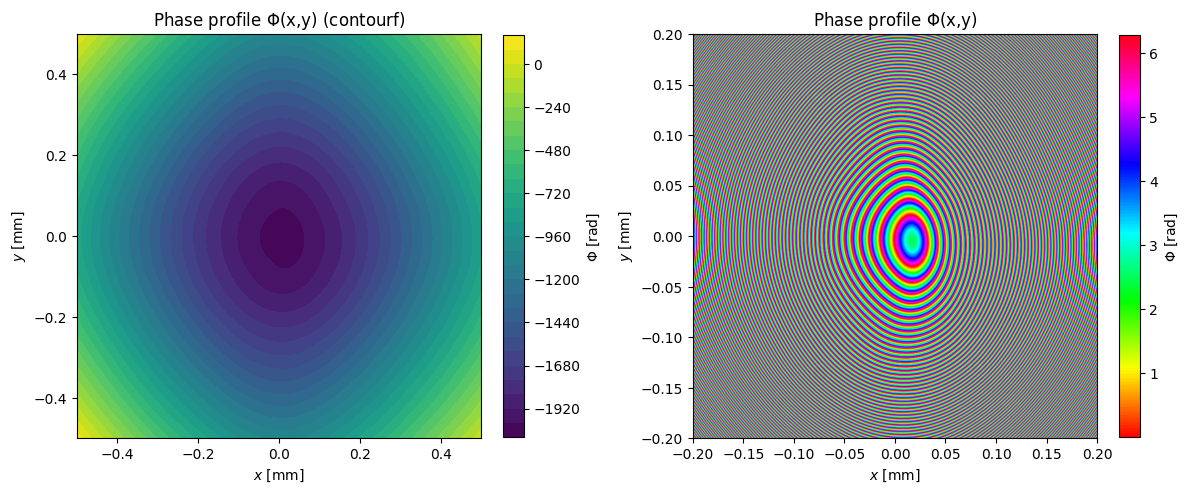

In [7]:
phi_spline = solver.get_phi_spline()


nx, ny = 2000, 2000
x = np.linspace(-solver.M, solver.M, nx)
y = np.linspace(-solver.M, solver.M, ny)
X, Y = np.meshgrid(x, y, indexing='xy')




fig, axs = plt.subplots(1, 2, figsize=(12, 6))
ax1 = axs[0]
im = ax1.contourf(phi_spline(x,y), origin = 'lower',  levels = 30, extent = [x[0]/mm, x[-1]/mm, y[0]/mm, y[-1]/mm])
cb = fig.colorbar(im, orientation = 'vertical',fraction=0.045, label = r'$\Phi$ [rad]')

ax1.set_ylabel("$y$ [mm]")
ax1.set_xlabel('$x$ [mm]')
ax1.set_title(r"Phase profile $\Phi$(x,y) (contourf)")
ax1.set_aspect(1) 

ax2 = axs[1]
im = ax2.imshow((phi_spline(x,y) )  %(np.pi*2), origin = 'lower', cmap = 'hsv', extent = [x[0]/mm, x[-1]/mm, y[0]/mm, y[-1]/mm])
cb = fig.colorbar(im, orientation = 'vertical',fraction=0.045, label = r'$\Phi$ [rad]')

ax2.set_ylabel("$y$ [mm]")
ax2.set_xlabel('$x$ [mm]')
ax2.set_title(r"Phase profile $\Phi$(x,y)")
ax2.set_aspect(1) 
ax2.set_xlim([-0.2, 0.2])
ax2.set_ylim([-0.2, 0.2])
fig.tight_layout()
plt.show()


## Scalar far-field diffraction validation
The PINN is trained from a ray/energy-conservation equation, but the resulting phase must also be checked with wave optics. Here the complex field just after the phase mask is assembled as

$$
U(x,y)=\sqrt{I(x,y)}\,e^{i\Phi(x,y)},
$$

and its scalar far field is computed with `MonochromaticField.get_farfield()` from `diffractsim`. The method returns the radiant intensity per projected solid angle,

$$
\frac{\partial P(\alpha,\beta)}{\partial\Omega\cos\theta},
$$

which is the same physical quantity used in the far-field Monge--Amp\`ere equation. Calling `get_farfield()` without angular intervals uses the natural FFT direction-cosine grid.

In [8]:
import jax
jax.config.update("jax_enable_x64", True)

from diffractsim import MonochromaticField

λ = 1.0 * um
Nx = 2048
Ny = 2048
extent_x = extent_source
extent_y = extent_source

# Diffractsim defines the centered source-plane sampling used by get_farfield().
F = MonochromaticField(
    wavelength=λ,
    extent_x=extent_x,
    extent_y=extent_y,
    Nx=Nx,
    Ny=Ny,
)

def I_fun(x, y):
    # Source function: Gaussian beam with beam waist w_I.
    r = np.sqrt(x**2 + y**2)
    return np.exp(-(r / w_I)**2)**2


# Complex field immediately after the PINN phase mask.
F.E = np.sqrt(I_fun(F.xx, F.yy)) * np.exp(1j * phi_spline(F.x, F.y))
α, β, radiant_intensity_percos = F.get_farfield()


## Plot the PINN far-field result

The left panel shows the simulated far-field intensity over the angular square. The right panel compares the central cross section at $\beta=0$ against the prescribed target profile. This is a simple way to check whether the DT peaks and the flat-top support are reproduced along the horizontal symmetry line.

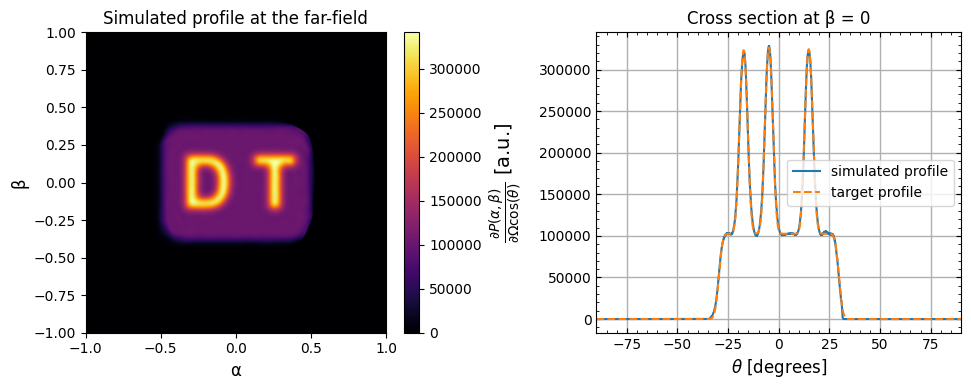

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

ax1 = axs[0]
im = ax1.imshow(radiant_intensity_percos, origin = 'lower', cmap ='inferno', extent = [α[0], α[-1], β[0],  β[-1] ], aspect = 'auto')
cb = fig.colorbar(im, orientation = 'vertical',fraction=0.045)
cb.set_label(label = r'$\frac{\partial P(α, β)}{\partial \Omega \cos(\theta)}$ [a.u.]', size = 14)

ax1.set_ylabel("β", size= 12)
ax1.set_xlabel('α', size= 12)
ax1.set_title(r"Simulated profile at the far-field")
ax1.set_aspect(1) 
ax1.set_xlim([-1.0,1.0])
ax1.set_ylim([-1.0,1.0])



ax2 = axs[1]
ax2.tick_params(axis='both', which="both", direction="in",right=True, top=True,)
ax2.minorticks_on()
ax2.grid(which='major', linestyle='-', linewidth=1.0)
ax2.plot(np.arcsin(np.clip(α, -1,1)) *180/ np.pi, radiant_intensity_percos[Ny//2, :] , label = 'simulated profile' )
ax2.set_xlim([-90,90])

α_torch = torch.from_numpy(np.array(α,dtype='float32')).to('cuda')
ax2.plot(np.arcsin(np.clip(α, -1,1)) *180/ np.pi, solver.Irad_fun_norm(α_torch,α_torch*0).cpu().numpy().ravel(), '--', label = 'target profile' ) 
ax2.tick_params(axis='both', which ="both", direction="in",right=True, top=True)
ax2.minorticks_on()
ax2.set_title('Cross section at β = 0')
#ax2.set_ylabel("Intensity [a.u.]")
ax2.set_xlabel(r'$\theta$ [degrees]', size= 12)

ax2.legend()

fig.tight_layout()

plt.show()


## Gerchberg--Saxton comparison for the same far-field target

The next cells run a Gerchberg--Saxton (GS) phase-retrieval baseline using the same Gaussian input amplitude and DT target amplitude. GS alternates between source and Fourier planes:

$$
U \xrightarrow{\mathcal{F}} \tilde U,
$$

then replaces the amplitude in each plane while keeping the current phase. Unlike the PINN, GS does not enforce a smooth energy-conserving ray map, so it can recover the global target shape while producing speckle-like fluctuations.

### GS helper functions

This cell defines utilities for evaluating the target on the FFT angular grid and for running the GS iterations. The target amplitude is imposed in the Fourier plane, while the Gaussian source amplitude is imposed in the input plane.

In [10]:

# -----------------------------
# Gerchberg--Saxton utilities
# -----------------------------
import jax.numpy as jnp


def _to_numpy(a):
    """Small helper: convert NumPy/JAX/Torch-like arrays to NumPy arrays."""
    try:
        return np.asarray(a)
    except Exception:
        return np.array(a)


def evaluate_target_on_alpha_beta_grid(alpha, beta, chunk_rows=128):
    """
    Evaluate the normalized target radiant intensity solver.Irad_fun_norm(alpha,beta)
    on a NumPy/JAX alpha-beta grid without allocating the full Torch mesh at once.
    """
    device = next(solver.net.parameters()).device
    dtype = torch.float32

    alpha_np = np.asarray(alpha, dtype=np.float32)
    beta_np = np.asarray(beta, dtype=np.float32)
    alpha_t = torch.as_tensor(alpha_np, dtype=dtype, device=device)

    rows = []
    with torch.no_grad():
        for j0 in range(0, len(beta_np), chunk_rows):
            beta_chunk = torch.as_tensor(beta_np[j0:j0 + chunk_rows], dtype=dtype, device=device)
            AA, BB = torch.meshgrid(alpha_t, beta_chunk, indexing='xy')
            vals = solver.Irad_fun_norm(AA, BB).detach().cpu().numpy()
            rows.append(vals)

    return np.vstack(rows)


def gs_phase_retrieval_from_arrays(source_intensity, target_intensity, dx, dy, num_iter=60, random_seed=1):
    """
    Gerchberg--Saxton phase retrieval for a phase-only far-field beam shaper.

    Parameters
    ----------
    source_intensity : ndarray, shape (Ny, Nx)
        Input-plane irradiance sampled on the centered (x,y) grid.
    target_intensity : ndarray, shape (Ny, Nx)
        Desired far-field radiant intensity sampled on the centered FFT alpha-beta grid.
    dx, dy : float
        Source-plane sampling pitch.
    num_iter : int
        Number of GS iterations.

    Returns
    -------
    retrieved_phase : ndarray, shape (Ny, Nx)
        Retrieved source-plane phase on the centered (x,y) grid.
    error_list : list[float]
        RMS amplitude error in the Fourier plane at each iteration.
    """
    rng = np.random.default_rng(random_seed)

    source_amplitude = np.sqrt(np.maximum(source_intensity, 0.0))
    target_amplitude = np.sqrt(np.maximum(target_intensity, 0.0)) / (dx * dy)

    # FFT routines assume the origin is at array index 0. The input arrays are
    # sampled on centered coordinates, so we ifftshift before applying fft2.
    source_amplitude_j = jnp.asarray(np.fft.ifftshift(source_amplitude))
    target_amplitude_j = jnp.asarray(np.fft.ifftshift(target_amplitude))

    initial_phase = rng.uniform(-np.pi, np.pi, size=source_intensity.shape)
    U_p = source_amplitude_j * jnp.exp(1j * jnp.asarray(np.fft.ifftshift(initial_phase)))

    error_list = []
    for it in range(num_iter):
        # Enforce input-plane amplitude.
        U = source_amplitude_j * jnp.exp(1j * jnp.angle(U_p))

        # Propagate to the far field with FFT and enforce target amplitude.
        Uf = jnp.fft.fft2(U)
        Uf_p = target_amplitude_j * jnp.exp(1j * jnp.angle(Uf))

        # Back-propagate to the input plane.
        U_p = jnp.fft.ifft2(Uf_p)

        diff = jnp.abs(Uf) - target_amplitude_j
        error_list.append(float(jnp.sqrt(jnp.mean(diff**2))))

        if (it + 1) % max(1, num_iter // 10) == 0:
            print(f"GS iteration {it + 1:4d}/{num_iter}: Fourier-amplitude RMS = {error_list[-1]:.6e}")

    retrieved_phase = np.fft.fftshift(np.asarray(jnp.angle(U_p)))
    return retrieved_phase, error_list


### Build the GS problem on the same grid

The GS calculation is constructed on the same spatial grid and far-field angular grid used for the PINN validation. This makes the comparison fair: both methods are propagated and evaluated with the same sampling conventions.

GS iteration    6/60: Fourier-amplitude RMS = 2.063361e+02
GS iteration   12/60: Fourier-amplitude RMS = 1.828410e+02
GS iteration   18/60: Fourier-amplitude RMS = 1.732733e+02
GS iteration   24/60: Fourier-amplitude RMS = 1.677930e+02
GS iteration   30/60: Fourier-amplitude RMS = 1.641515e+02
GS iteration   36/60: Fourier-amplitude RMS = 1.615376e+02
GS iteration   42/60: Fourier-amplitude RMS = 1.595310e+02
GS iteration   48/60: Fourier-amplitude RMS = 1.579365e+02
GS iteration   54/60: Fourier-amplitude RMS = 1.566326e+02
GS iteration   60/60: Fourier-amplitude RMS = 1.555297e+02


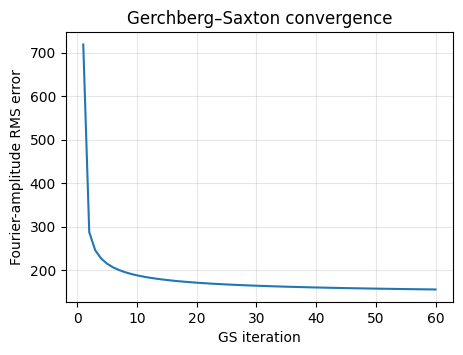

In [13]:

# -----------------------------
# Build the GS problem on the same grid used for the PINN far-field validation
# -----------------------------
# Reuse Nx, Ny, x, y, xx, yy, dx, dy, α, β, and radiant_intensity_percos from the PINN validation cells above.
# If desired, lower num_iter_gs for a quick test or increase it for a better GS solution.
num_iter_gs = 60
xx, yy = F.xx, F.yy
dx, dy = F.dx, F.dy
# Source irradiance sampled on the input plane.
source_intensity_gs = I_fun(xx, yy)

# Target radiant intensity sampled on the same natural FFT alpha-beta grid.
target_intensity_gs = evaluate_target_on_alpha_beta_grid(α, β, chunk_rows=128)

# Run GS.
retrieved_phase_gs, gs_error_list = gs_phase_retrieval_from_arrays(
    source_intensity=source_intensity_gs,
    target_intensity=target_intensity_gs,
    dx=dx,
    dy=dy,
    num_iter=num_iter_gs,
    random_seed=1,
)

# Plot GS convergence.
fig = plt.figure(figsize=(5, 3.5))
ax = fig.add_subplot(1, 1, 1)
ax.plot(np.arange(1, len(gs_error_list) + 1), gs_error_list)
ax.set_xlabel('GS iteration')
ax.set_ylabel('Fourier-amplitude RMS error')
ax.set_title('Gerchberg–Saxton convergence')
ax.grid(alpha=0.3)
plt.show()


### Propagate and inspect the GS solution

The retrieved GS phase is converted into a phase-only field and propagated to the far field. These plots show whether the GS phase produces the DT target and how structured or noisy the retrieved phase mask is.

Max |α_PINN - α_GS|: 0.0
Max |β_PINN - β_GS|: 0.0


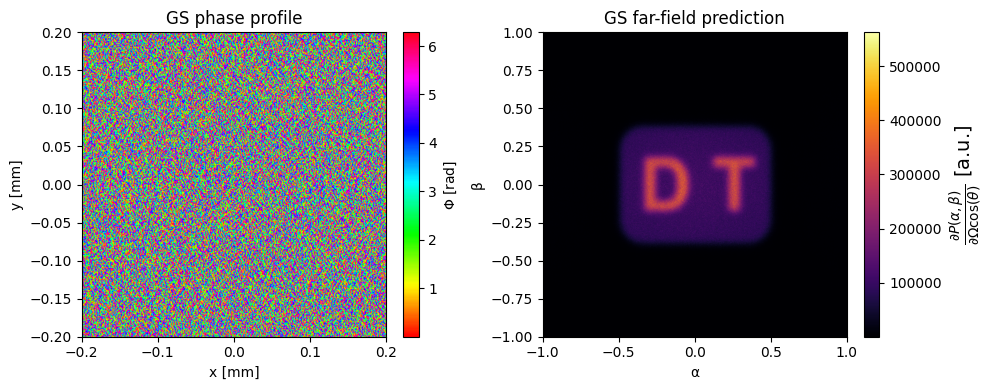

In [16]:

# -----------------------------
# Propagate the GS phase to the far field
# -----------------------------
E_gs = np.sqrt(np.maximum(source_intensity_gs, 0.0)) * np.exp(1j * retrieved_phase_gs)
F.E = np.asarray(E_gs, dtype=np.complex128)
α_gs, β_gs, radiant_intensity_percos_gs = F.get_farfield()

# Convert Diffractsim outputs to NumPy for plotting and comparison.
α_np = np.asarray(α)
β_np = np.asarray(β)
radiant_intensity_percos_pinn = np.asarray(radiant_intensity_percos)
α_gs_np = np.asarray(α_gs)
β_gs_np = np.asarray(β_gs)
radiant_intensity_percos_gs = np.asarray(radiant_intensity_percos_gs)

# The GS and PINN validations use the same x-y sampling, so their alpha-beta grids should match.
print('Max |α_PINN - α_GS|:', np.max(np.abs(α_np - α_gs_np)))
print('Max |β_PINN - β_GS|:', np.max(np.abs(β_np - β_gs_np)))

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

im0 = axs[0].imshow((retrieved_phase_gs % (2*np.pi)), origin='lower', cmap='hsv',
                    extent=[x[0]/mm, x[-1]/mm, y[0]/mm, y[-1]/mm])
axs[0].set_title('GS phase profile')
axs[0].set_xlabel('x [mm]')
axs[0].set_ylabel('y [mm]')
axs[0].set_xlim([-0.2, 0.2])
axs[0].set_ylim([-0.2, 0.2])
axs[0].set_aspect(1)
fig.colorbar(im0, ax=axs[0], fraction=0.045, label=R'$\Phi$ [rad]')

im1 = axs[1].imshow(radiant_intensity_percos_gs, origin='lower', cmap='inferno',
                    extent=[α_gs_np[0], α_gs_np[-1], β_gs_np[0], β_gs_np[-1]], aspect='auto')
axs[1].set_title('GS far-field prediction')
axs[1].set_xlabel('α')
axs[1].set_ylabel('β')
axs[1].set_xlim([-1, 1])
axs[1].set_ylim([-1, 1])
axs[1].set_aspect(1)
cb = fig.colorbar(im1, ax=axs[1], fraction=0.045,
             label = r'$\frac{\partial P(α, β)}{\partial \Omega \cos(\theta)}$ [a.u.]')
cb.set_label(label = r'$\frac{\partial P(α, β)}{\partial \Omega \cos(\theta)}$ [a.u.]', size = 14)

fig.tight_layout()
plt.show()


### Zoomed GS view

This zoom focuses on the central aperture and central angular region, where the DT target is located. It highlights the local phase variations produced by GS and the corresponding far-field structure around the target support.

Max |α_PINN - α_GS|: 0.0
Max |β_PINN - β_GS|: 0.0


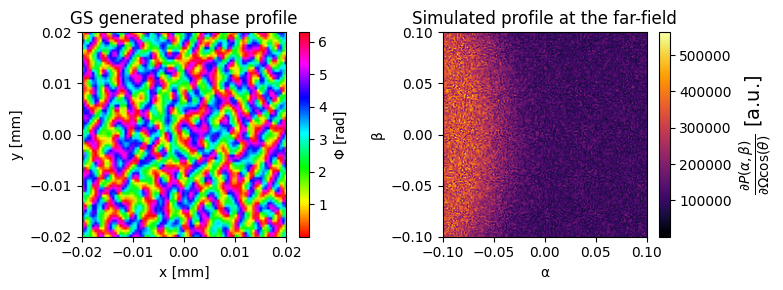

In [19]:

# -----------------------------
# Propagate the GS phase to the far field
# -----------------------------
E_gs = np.sqrt(np.maximum(source_intensity_gs, 0.0)) * np.exp(1j * retrieved_phase_gs)
F.E = np.asarray(E_gs, dtype=np.complex128)
α_gs, β_gs, radiant_intensity_percos_gs = F.get_farfield()

# Convert Diffractsim outputs to NumPy for plotting and comparison.
α_np = np.asarray(α)
β_np = np.asarray(β)
radiant_intensity_percos_pinn = np.asarray(radiant_intensity_percos)
α_gs_np = np.asarray(α_gs)
β_gs_np = np.asarray(β_gs)
radiant_intensity_percos_gs = np.asarray(radiant_intensity_percos_gs)

# The GS and PINN validations use the same x-y sampling, so their alpha-beta grids should match.
print('Max |α_PINN - α_GS|:', np.max(np.abs(α_np - α_gs_np)))
print('Max |β_PINN - β_GS|:', np.max(np.abs(β_np - β_gs_np)))

fig, axs = plt.subplots(1, 2, figsize=(8, 3))

im0 = axs[0].imshow((retrieved_phase_gs % (2*np.pi)), origin='lower', cmap='hsv',
                    extent=[x[0]/mm, x[-1]/mm, y[0]/mm, y[-1]/mm] , interpolation = None)
axs[0].set_title('GS generated phase profile')
axs[0].set_xlabel('x [mm]')
axs[0].set_ylabel('y [mm]')
axs[0].set_xlim([-0.02, 0.02])
axs[0].set_ylim([-0.02, 0.02])
axs[0].set_aspect(1)
fig.colorbar(im0, ax=axs[0], fraction=0.045, label=r'$\Phi$ [rad]')

im1 = axs[1].imshow(radiant_intensity_percos_gs, origin='lower', cmap='inferno',
                    extent=[α_gs_np[0], α_gs_np[-1], β_gs_np[0], β_gs_np[-1]], aspect='auto')
axs[1].set_title('Simulated profile at the far-field')
axs[1].set_xlabel('α')
axs[1].set_ylabel('β')
axs[1].set_xlim([-0.1, 0.1])
axs[1].set_ylim([-0.1, 0.1])
axs[1].set_aspect(1)
cb = fig.colorbar(im1, ax=axs[1], fraction=0.045,
             label=r'$\partial P/(\partial\Omega\cos\theta)$ [a.u.]')
cb.set_label(label = r'$\frac{\partial P(α, β)}{\partial \Omega \cos(\theta)}$ [a.u.]', size = 14)

fig.tight_layout()
plt.show()


## Shape-error comparison on $[-1,1]\times[-1,1]$

The PINN and GS intensities can have different overall normalizations. Before computing the error, each prediction is multiplied by the least-squares scalar $s$ that minimizes

$$
\|s I_{\mathrm{pred}}-I_{\mathrm{target}}\|_2^2
$$

inside the comparison region. The notebook then reports the RMS and relative RMS errors and plots the target, PINN, and GS intensity maps on the same angular domain.

RMS error on (α,β) ∈ [-1,1]²
  PINN: 1.894853e+03   relative RMS: 2.970030e-02   scale factor: 9.989771e-01
  GS:   1.442601e+04   relative RMS: 2.261161e-01   scale factor: 9.931816e-01


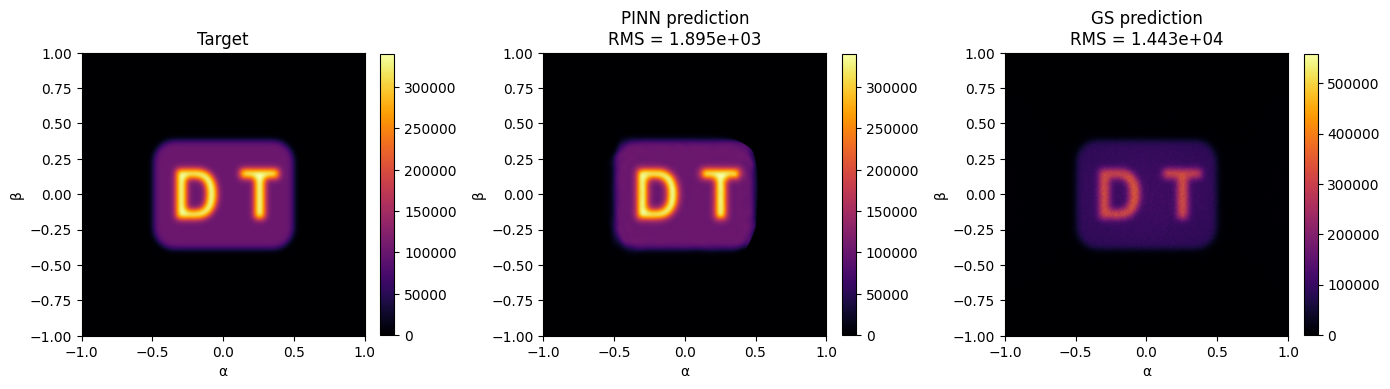

In [20]:

# -----------------------------
# RMS comparison on the square (α, β) in [-1, 1] x [-1, 1]
# -----------------------------
def least_squares_rescale(pred, target, mask):
    """Return pred multiplied by the scalar minimizing ||s*pred - target|| on mask."""
    p = np.asarray(pred, dtype=np.float64)[mask]
    t = np.asarray(target, dtype=np.float64)[mask]
    denom = np.sum(p * p)
    scale = 0.0 if denom == 0 else np.sum(p * t) / denom
    return scale * np.asarray(pred, dtype=np.float64), scale

# Square comparison region requested by the user.
alpha_mask = (α_np >= -1.0) & (α_np <= 1.0)
beta_mask = (β_np >= -1.0) & (β_np <= 1.0)
region_mask = np.outer(beta_mask, alpha_mask)

# Target on the same grid. This was already evaluated above for GS.
target_compare = np.asarray(target_intensity_gs, dtype=np.float64)

# Rescale each prediction to the target before computing RMS.
pinn_scaled, pinn_scale = least_squares_rescale(radiant_intensity_percos_pinn, target_compare, region_mask)
gs_scaled, gs_scale = least_squares_rescale(radiant_intensity_percos_gs, target_compare, region_mask)

rms_pinn = np.sqrt(np.mean((pinn_scaled[region_mask] - target_compare[region_mask])**2))
rms_gs = np.sqrt(np.mean((gs_scaled[region_mask] - target_compare[region_mask])**2))

# Optional relative RMS values, normalized by the target RMS in the same region.
target_rms = np.sqrt(np.mean(target_compare[region_mask]**2))
rel_rms_pinn = rms_pinn / target_rms
rel_rms_gs = rms_gs / target_rms

print('RMS error on (α,β) ∈ [-1,1]²')
print(f'  PINN: {rms_pinn:.6e}   relative RMS: {rel_rms_pinn:.6e}   scale factor: {pinn_scale:.6e}')
print(f'  GS:   {rms_gs:.6e}   relative RMS: {rel_rms_gs:.6e}   scale factor: {gs_scale:.6e}')

fig, axs = plt.subplots(1, 3, figsize=(14, 4))

vmax = np.percentile(target_compare[region_mask], 99.5)
for ax, img, title in [
    (axs[0], target_compare, 'Target'),
    (axs[1], pinn_scaled, f'PINN prediction\nRMS = {rms_pinn:.3e}'),
    (axs[2], gs_scaled, f'GS prediction\nRMS = {rms_gs:.3e}'),
]:
    im = ax.imshow(img, origin='lower', cmap='inferno',
                   extent=[α_np[0], α_np[-1], β_np[0], β_np[-1]],
                   vmin=0,  aspect='auto')
    ax.set_title(title)
    ax.set_xlabel('α')
    ax.set_ylabel('β')
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_aspect(1)
    fig.colorbar(im, ax=ax, fraction=0.045)

fig.tight_layout()
plt.show()


## Central cross-section comparison

The cross section at $\beta=0$ compares the target, PINN, and GS predictions along the line that cuts through the main DT features. This plot makes the speckle and oscillations in GS easier to see relative to the smoother PINN prediction.

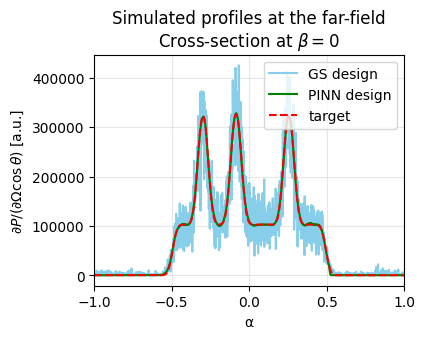

In [21]:

# -----------------------------
# Cross-section at β = 0 for target, PINN and GS
# -----------------------------
beta0_idx = int(np.argmin(np.abs(β_np)))

fig = plt.figure(figsize=(4, 3))
ax = fig.add_subplot(1, 1, 1)
ax.plot(α_np, gs_scaled[beta0_idx, :], color =  'skyblue', label='GS design')
ax.plot(α_np, pinn_scaled[beta0_idx, :], color =  'green', label='PINN design')

ax.plot(α_np, target_compare[beta0_idx, :], '--',color =  'red',  label='target')

ax.set_xlim([-1, 1])
ax.set_xlabel('α')
ax.set_ylabel(r'$\partial P/(\partial\Omega\cos\theta)$ [a.u.]')
ax.set_title('Simulated profiles at the far-field\n' 
             r'Cross-section at $\beta = 0$')
ax.grid(alpha=0.3)
ax.legend()
plt.show()


## Energy-efficiency comparison: PINN vs Gerchberg--Saxton

Here the energy efficiency is defined as

$$
\eta = \frac{\text{energy flux delivered into the target support}}{\text{incident energy flux}}.
$$

The numerator integrates the simulated far-field intensity over the support of the DT target, while the denominator integrates the input Gaussian irradiance over the source aperture. This metric is complementary to shape error: it measures how much optical power is directed into the desired region, regardless of small intensity-profile deviations within that region.

Energy-efficiency comparison
  Target support threshold: 3.405569e+02
  Target support area in alpha-beta space: 9.510690e-01
  Incident energy flux: 1.005296e+05
  PINN target-area flux: 1.005117e+05
  GS target-area flux:   9.640640e+04
  PINN efficiency: 99.982228%
  GS efficiency:   95.898563%

Sanity checks on [-1,1]²:
  PINN total far-field flux in [-1,1]²: 1.005296e+05
  GS total far-field flux in [-1,1]²:   1.002863e+05
  Target-design flux over target support: 1.005208e+05


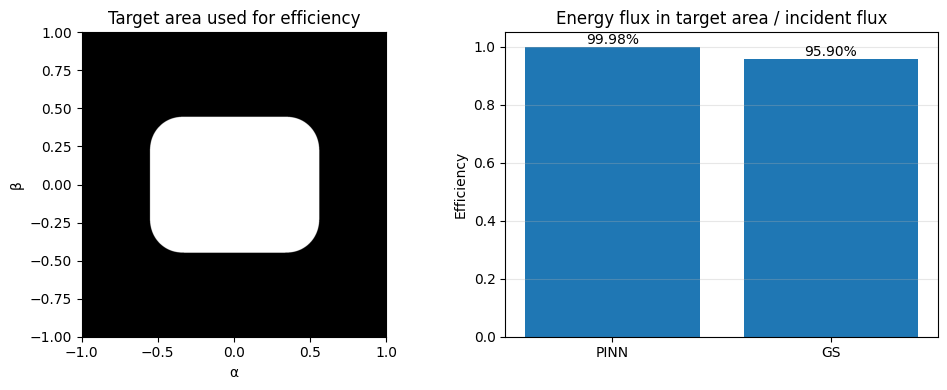

In [22]:

# -----------------------------
# Energy-efficiency comparison: energy in the target area / incident energy
# -----------------------------
def regular_grid_spacing(grid_1d):
    """Return the absolute spacing of a regular 1D grid."""
    grid_1d = np.asarray(grid_1d, dtype=np.float64)
    if grid_1d.size < 2:
        return 1.0
    return float(np.abs(np.mean(np.diff(grid_1d))))


def integrate_on_grid(values, dx0, dx1, mask=None):
    """Integral of a 2D array on a regular grid, optionally restricted to mask."""
    vals = np.asarray(values, dtype=np.float64)
    if mask is not None:
        vals = np.where(mask, vals, 0.0)
    return float(np.sum(vals) * dx0 * dx1)


def energy_efficiency_farfield(prediction, target_support_mask, incident_flux, d_alpha, d_beta):
    """Compute eta = far-field energy in target support / incident energy flux."""
    target_flux = integrate_on_grid(prediction, d_alpha, d_beta, mask=target_support_mask)
    eta = target_flux / incident_flux if incident_flux != 0 else np.nan
    return eta, target_flux

# Incident energy flux at the phase mask / source plane.
incident_flux = integrate_on_grid(source_intensity_gs, dx, dy)

# Angular-grid area element for the far-field prediction.
d_alpha = regular_grid_spacing(α_np)
d_beta = regular_grid_spacing(β_np)

# Define the target area from the target profile itself.
# The comparison is restricted to the requested angular square [-1,1] x [-1,1].
# Increase target_support_threshold if you want a stricter definition of the flat-top support.
target_support_threshold = 1e-3 * np.nanmax(target_compare)
target_support_mask = region_mask & (target_compare > target_support_threshold)

# Use the raw physical predictions, not the least-squares-rescaled fields used for shape RMS.
eff_pinn, target_flux_pinn = energy_efficiency_farfield(
    radiant_intensity_percos_pinn,
    target_support_mask,
    incident_flux,
    d_alpha,
    d_beta,
)

eff_gs, target_flux_gs = energy_efficiency_farfield(
    radiant_intensity_percos_gs,
    target_support_mask,
    incident_flux,
    d_alpha,
    d_beta,
)

# Optional sanity checks: total far-field flux in the plotted alpha-beta square and target-design flux.
total_flux_pinn_region = integrate_on_grid(radiant_intensity_percos_pinn, d_alpha, d_beta, mask=region_mask)
total_flux_gs_region = integrate_on_grid(radiant_intensity_percos_gs, d_alpha, d_beta, mask=region_mask)
target_design_flux = integrate_on_grid(target_compare, d_alpha, d_beta, mask=target_support_mask)

target_area = float(np.sum(target_support_mask) * d_alpha * d_beta)

print('Energy-efficiency comparison')
print(f'  Target support threshold: {target_support_threshold:.6e}')
print(f'  Target support area in alpha-beta space: {target_area:.6e}')
print(f'  Incident energy flux: {incident_flux:.6e}')
print(f'  PINN target-area flux: {target_flux_pinn:.6e}')
print(f'  GS target-area flux:   {target_flux_gs:.6e}')
print(f'  PINN efficiency: {eff_pinn:.6%}')
print(f'  GS efficiency:   {eff_gs:.6%}')
print('')
print('Sanity checks on [-1,1]²:')
print(f'  PINN total far-field flux in [-1,1]²: {total_flux_pinn_region:.6e}')
print(f'  GS total far-field flux in [-1,1]²:   {total_flux_gs_region:.6e}')
print(f'  Target-design flux over target support: {target_design_flux:.6e}')

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Visualize the mask used for the numerator.
axs[0].imshow(target_support_mask.astype(float), origin='lower', cmap='gray',
              extent=[α_np[0], α_np[-1], β_np[0], β_np[-1]], aspect='auto')
axs[0].set_title('Target area used for efficiency')
axs[0].set_xlabel('α')
axs[0].set_ylabel('β')
axs[0].set_xlim([-1, 1])
axs[0].set_ylim([-1, 1])
axs[0].set_aspect(1)

axs[1].bar(['PINN', 'GS'], [eff_pinn, eff_gs])
axs[1].set_ylabel('Efficiency')
axs[1].set_title('Energy flux in target area / incident flux')
axs[1].set_ylim(0, 1.05 * max(eff_pinn, eff_gs, 1e-12))
axs[1].grid(axis='y', alpha=0.3)
for i, eff in enumerate([eff_pinn, eff_gs]):
    axs[1].text(i, eff, f'{100*eff:.2f}%', ha='center', va='bottom')

fig.tight_layout()
plt.show()
